# Reading Dataset (Mnist)

In [9]:
import idx2numpy

train_images_path = "train-images.idx3-ubyte"
train_labels_path = "train-labels.idx1-ubyte"
test_images_path = "t10k-images.idx3-ubyte"
test_labels_path = "t10k-labels.idx1-ubyte"

X_train = idx2numpy.convert_from_file(train_images_path)
y_train = idx2numpy.convert_from_file(train_labels_path)
X_test = idx2numpy.convert_from_file(test_images_path)
y_test = idx2numpy.convert_from_file(test_labels_path)

print(f"Original Training images shape: {X_train.shape}, Training labels shape: {y_train.shape}")
print(f"Original Test images shape: {X_test.shape}, Test labels shape: {y_test.shape}")

X_train_flattened = X_train.reshape(X_train.shape[0], -1)  # Flatten to (n_samples, 784)
X_test_flattened = X_test.reshape(X_test.shape[0], -1)     # Flatten test set similarly

print(f"Flattened Training images shape: {X_train_flattened.shape}")
print(f"Flattened Test images shape: {X_test_flattened.shape}")

Original Training images shape: (60000, 28, 28), Training labels shape: (60000,)
Original Test images shape: (10000, 28, 28), Test labels shape: (10000,)
Flattened Training images shape: (60000, 784)
Flattened Test images shape: (10000, 784)


# Preprocessing Dataset

In [10]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

# Normalize the pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape to add channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# One-hot encode the labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print(f"Training images shape: {X_train.shape}, Training labels shape: {y_train.shape}")
print(f"Test images shape: {X_test.shape}, Test labels shape: {y_test.shape}")


Training images shape: (60000, 28, 28, 1), Training labels shape: (60000, 10)
Test images shape: (10000, 28, 28, 1), Test labels shape: (10000, 10)


# LeNet-5 Model

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Define the LeNet-5 model
lenet_model = Sequential([
    Conv2D(6, kernel_size=(5, 5), activation='relu', input_shape=(28, 28, 1), padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    
    Conv2D(16, kernel_size=(5, 5), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    
    Dense(120, activation='relu'),
    Dense(84, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile the model
lenet_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
lenet_model.fit(X_train, y_train, epochs=5, batch_size=128, validation_data=(X_test, y_test))


Epoch 1/5
469/469 [==============================] - 26s 48ms/step - loss: 0.3089 - accuracy: 0.9080 - val_loss: 0.0871 - val_accuracy: 0.9722
Epoch 2/5
469/469 [==============================] - 22s 48ms/step - loss: 0.0808 - accuracy: 0.9756 - val_loss: 0.0580 - val_accuracy: 0.9823
Epoch 3/5
469/469 [==============================] - 27s 58ms/step - loss: 0.0574 - accuracy: 0.9818 - val_loss: 0.0439 - val_accuracy: 0.9853
Epoch 4/5
469/469 [==============================] - 22s 46ms/step - loss: 0.0461 - accuracy: 0.9859 - val_loss: 0.0429 - val_accuracy: 0.9853
Epoch 5/5
469/469 [==============================] - 24s 50ms/step - loss: 0.0377 - accuracy: 0.9880 - val_loss: 0.0465 - val_accuracy: 0.9840


In [14]:
loss, accuracy = lenet_model.evaluate(X_test, y_test)
print(f"LeNet-5 Test Accuracy: {accuracy:.2f}")




313/313 [==============================] - 3s 9ms/step - loss: 0.0465 - accuracy: 0.9840
LeNet-5 Test Accuracy: 0.98


'loss, accuracy = vgg_model.evaluate(X_test, y_test)\nprint(f"VGG-16 Test Accuracy: {accuracy:.2f}")'

# VGG-16 Model

In [13]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Input, Dense, Flatten
from tensorflow.keras.models import Sequential
import tensorflow as tf

# Resize images to 32x32
X_train_resized = tf.image.resize(X_train, (32, 32))
X_test_resized = tf.image.resize(X_test, (32, 32))

# VGG-16 expects 3-channel input, so replicate the grayscale channel
X_train_resized = tf.repeat(X_train_resized, 3, axis=-1)  # (n_samples, 32, 32, 3)
X_test_resized = tf.repeat(X_test_resized, 3, axis=-1)    # (n_samples, 32, 32, 3)

# Load the VGG-16 base model without the top layer
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# Add custom classification layers
vgg_model = Sequential([
    vgg_base,
    Flatten(),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')  # 10 classes for MNIST
])

# Compile the model
vgg_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
vgg_model.fit(X_train_resized, y_train, epochs=5, batch_size=128, validation_data=(X_test_resized, y_test))


KeyboardInterrupt: 

# Code output taken from google colab due to faster runtime environment of GPU

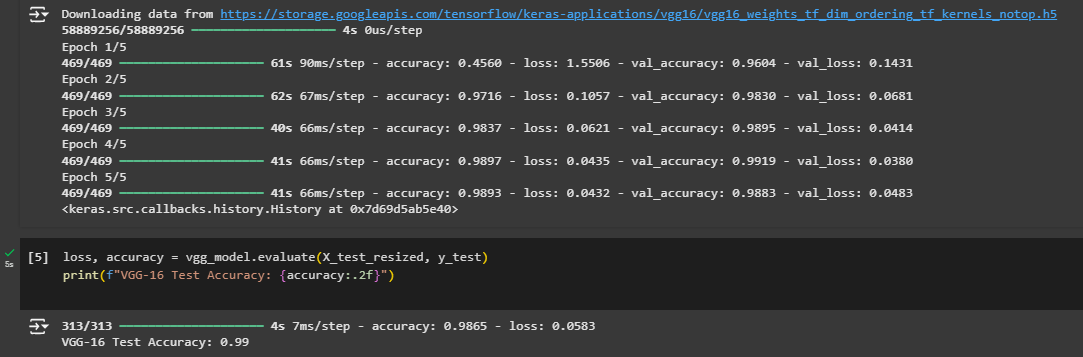

In [ ]:
loss, accuracy = vgg_model.evaluate(X_test, y_test)
print(f"VGG-16 Test Accuracy: {accuracy:.2f}")

# Comparison b/w the LeNet-5 and VGG-16:


### Accuracy for VGG-16 is found to be around 0.99 whereas the accuracy of LeNet-5 is 0.98, therefore we can conclude from here that our results came better with the VGG-16 model
